# 极坐标 SNO：Operator Learner 训练

本 Notebook 只训练 Operator Learner（OL），不重新训练 Function Encoder（FE）。训练过程为：

\[
(z_f,\,g_n,\,k) \longmapsto z_P \longmapsto P(r,	heta).
\]

主要特性：

- 从已保存的 `fe_params.msgpack` 恢复并冻结 FE；
- OL 每一步都从 PI-sampler 分布生成新的训练 batch，不使用固定 pool；
- 使用 `tqdm` 显示训练进度；
- 定期在独立新样本上记录潜空间 MSE、潜空间相对 L2 和物理空间相对 L2；
- 持续保存 CSV、NPZ 和最新 OL checkpoint。

## 1. GPU 环境

以下单元必须在导入 JAX 前运行。如果当前内核已经导入过 JAX，请先重启内核。`GPU_ID` 使用重映射前的服务器 GPU 编号。

In [9]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

GPU_ID = "5"  # 按服务器实际情况修改
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# 如需限制显存比例，可取消下一行注释：
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.85"

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 5


## 2. 导入项目代码

服务器环境需安装 `requirements.txt` 中的依赖，尤其是新增的 `tqdm`：

```bash
pip install -r requirements.txt
```

In [10]:
from pathlib import Path
from dataclasses import fields, replace
import json
import sys

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import serialization

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "config_polar.py").exists():
    PROJECT_DIR = Path("/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code")

if not (PROJECT_DIR / "config_polar.py").exists():
    raise FileNotFoundError("PROJECT_DIR 中找不到 config_polar.py，请修改项目路径。")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from config_polar import PolarAnnulusConfig
from data_polar import sample_batch
from train_polar import (
    create_fe_state,
    load_normalizer,
    train_operator,
)

print("Project directory:", PROJECT_DIR)
print("JAX devices:", jax.devices())

Project directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code
JAX devices: [CudaDevice(id=0)]


## 3. 从 FE 训练目录恢复配置

直接读取 FE 训练时保存的 `config.json`，避免手动复制网络维度造成 checkpoint 结构不匹配。旧配置若缺少新的 OL 日志字段，会自动采用默认值。

In [11]:
FE_RUN_NAME = "polar_v3"
OUTPUT_ROOT = PROJECT_DIR / "out_polar_annulus_sno"
fe_run_dir = OUTPUT_ROOT / FE_RUN_NAME
config_path = fe_run_dir / "config.json"

if not config_path.exists():
    raise FileNotFoundError(f"找不到 FE 配置：{config_path}")

saved_config = json.loads(config_path.read_text(encoding="utf-8"))
valid_config_fields = {field.name for field in fields(PolarAnnulusConfig)}
unknown_fields = sorted(set(saved_config) - valid_config_fields)
if unknown_fields:
    print("Ignoring unknown config fields:", unknown_fields)

config_kwargs = {
    key: value
    for key, value in saved_config.items()
    if key in valid_config_fields
}
config_kwargs["out_dir"] = str(OUTPUT_ROOT)
config_kwargs["run_name"] = FE_RUN_NAME

# 兼容重构前保存的旧 config.json。
config_kwargs.setdefault("ol_log_interval", 500)
config_kwargs.setdefault("ol_checkpoint_interval", 10_000)
config_kwargs.setdefault("ol_eval_sample_size", 16)
config_kwargs.setdefault("ol_eval_probe_points", 256)

cfg = PolarAnnulusConfig(**config_kwargs)

print("FE run directory:", fe_run_dir)
print("Effective full batch size:", cfg.effective_batch_size)
print("OL steps in saved config:", cfg.ol_steps)
print("OL log interval:", cfg.ol_log_interval)
print("OL checkpoint interval:", cfg.ol_checkpoint_interval)
print("OL eval sample size per scale:", cfg.ol_eval_sample_size)
print("OL eval probe points:", cfg.ol_eval_probe_points)

FE run directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v3
Effective full batch size: 768
OL steps in saved config: 200000
OL log interval: 500
OL checkpoint interval: 10000
OL eval sample size per scale: 16
OL eval probe points: 256


## 4. 选择 smoke 或 full 模式

第一次运行必须先用 `smoke`。确认进度条、日志和 checkpoint 正常产生后，再切换为 `full`。

- `smoke`：使用相同网络结构和 FE 权重，但只采一个先验尺度、每步 2 个样本、训练 5 步，并输出到独立目录。
- `full`：使用 FE 训练时的完整采样分布和正式训练步数。

In [12]:
OL_RUN_MODE = "full"  # "smoke" 或 "full"

if OL_RUN_MODE == "smoke":
    ol_cfg = replace(
        cfg,
        prior_scale_pairs=(cfg.prior_scale_pairs[0],),
        repeats_per_scale=1,
        sample_size=2,
        ol_steps=5,
        ol_log_interval=1,
        ol_checkpoint_interval=5,
        ol_eval_sample_size=2,
        ol_eval_probe_points=4,
        run_name=f"{cfg.run_name}_ol_smoke",
    )
else:
    ol_cfg = replace(
        cfg,
        sample_size = 128,
        ol_steps=300_000,
        ol_log_interval=500,
        ol_checkpoint_interval=10_000,
        ol_eval_sample_size=32,
        ol_eval_probe_points=1024,
    )

print("OL mode:", OL_RUN_MODE)
print("OL output directory:", ol_cfg.output_dir)
print("OL effective batch size:", ol_cfg.effective_batch_size)
print("OL steps:", ol_cfg.ol_steps)
print("Log every:", ol_cfg.ol_log_interval, "steps")
print("Checkpoint every:", ol_cfg.ol_checkpoint_interval, "steps")
print("Eval sample size per scale:", ol_cfg.ol_eval_sample_size)
print("Eval probe points:", ol_cfg.ol_eval_probe_points)

OL mode: full
OL output directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v3
OL effective batch size: 384
OL steps: 300000
Log every: 500 steps
Checkpoint every: 10000 steps
Eval sample size per scale: 32
Eval probe points: 1024


## 5. 加载并冻结 Function Encoder

FE 权重和归一化统计量始终从正式 FE 目录读取。`smoke` 只改变采样批量和 OL 输出目录，不改变 FE 网络结构。

In [13]:
fe_checkpoint_path = fe_run_dir / "fe_params.msgpack"
if not fe_checkpoint_path.exists():
    raise FileNotFoundError(f"找不到 FE checkpoint：{fe_checkpoint_path}")

fe_state_for_ol, _ = create_fe_state(
    cfg,
    jax.random.PRNGKey(cfg.seed + 30_000),
)
loaded_fe_params = serialization.from_bytes(
    fe_state_for_ol.params,
    fe_checkpoint_path.read_bytes(),
)
fe_state_for_ol = fe_state_for_ol.replace(params=loaded_fe_params)
normalizer_for_ol = load_normalizer(fe_run_dir)

print("Loaded FE checkpoint:", fe_checkpoint_path)
print(
    "Normalizer:",
    f"std_P={float(normalizer_for_ol.std_p):.6e}",
    f"mean_f={float(normalizer_for_ol.mean_f):.6e}",
    f"std_f={float(normalizer_for_ol.std_f):.6e}",
)

Loaded FE checkpoint: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v3/fe_params.msgpack
Normalizer: std_P=4.162077e-01 mean_f=-5.124479e-03 std_f=1.334440e+01


## 6. 训练前检查一个新 batch

这里仅验证采样结果的形状和有限性。正式训练时，`train_operator` 会在每一步重新生成 batch。

In [14]:
check_batch = sample_batch(
    jax.random.PRNGKey(ol_cfg.seed + 40_000),
    ol_cfg,
)

for name, value in check_batch._asdict().items():
    assert bool(jnp.all(jnp.isfinite(value))), f"{name} contains NaN/Inf"
    print(f"{name:16s}: {value.shape}")

boundary_coords : (384, 128, 2)
boundary_flux   : (384, 128)
pod_coords      : (4096, 2)
probe_coords    : (1024, 2)
p_pod           : (384, 4096)
f_pod           : (384, 4096)
p_probe         : (384, 1024)
f_probe         : (384, 1024)
k_values        : (384,)


## 7. 训练 Operator Learner

运行后将显示 `tqdm` 进度条。每到日志间隔，会在独立的新评估 batch 上打印：

- `train_MSE`：训练 batch 潜空间 MSE；
- `eval_MSE`：独立 batch 潜空间 MSE；
- `RL2(z_P)`：潜空间相对 L2；
- `RL2(P@probe)`：解码到随机 probe 点后的物理压力相对 L2。

本单元每次执行都会从随机初始化重新开始 OL 训练。

In [ ]:
ol_state = train_operator(
    ol_cfg,
    fe_state_for_ol,
    normalizer_for_ol,
)

[OL eval] batch=96, probe_points=1024


Operator training:   0%|                                                                                      …

[OL 0000001] train_MSE=9.0489e-01 eval_MSE=1.1965e+00 RL2(z_P)=6.4209e+00 RL2(P@probe)=2.0898e+00
[OL 0000500] train_MSE=1.0609e-02 eval_MSE=1.0110e-02 RL2(z_P)=4.3985e-01 RL2(P@probe)=3.2586e-01
[OL 0001000] train_MSE=3.0537e-03 eval_MSE=3.0456e-03 RL2(z_P)=2.4514e-01 RL2(P@probe)=1.5758e-01
[OL 0001500] train_MSE=1.4285e-03 eval_MSE=1.7975e-03 RL2(z_P)=1.8697e-01 RL2(P@probe)=1.1303e-01
[OL 0002000] train_MSE=1.2997e-03 eval_MSE=1.1252e-03 RL2(z_P)=1.6101e-01 RL2(P@probe)=1.2270e-01
[OL 0002500] train_MSE=7.3924e-04 eval_MSE=5.9260e-04 RL2(z_P)=1.2014e-01 RL2(P@probe)=5.9268e-02
[OL 0003000] train_MSE=5.7763e-04 eval_MSE=5.4254e-04 RL2(z_P)=1.1545e-01 RL2(P@probe)=7.0449e-02
[OL 0003500] train_MSE=4.5828e-04 eval_MSE=4.1792e-04 RL2(z_P)=1.0217e-01 RL2(P@probe)=5.6560e-02
[OL 0004000] train_MSE=4.9168e-04 eval_MSE=5.2702e-04 RL2(z_P)=1.2895e-01 RL2(P@probe)=9.2654e-02
[OL 0004500] train_MSE=3.1016e-04 eval_MSE=3.2615e-04 RL2(z_P)=8.7953e-02 RL2(P@probe)=4.5125e-02
[OL 0005000] train_M

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[OL 0076500] train_MSE=3.4795e-05 eval_MSE=3.4967e-05 RL2(z_P)=2.6968e-02 RL2(P@probe)=1.6705e-02
[OL 0077000] train_MSE=5.4977e-05 eval_MSE=4.0420e-05 RL2(z_P)=2.9268e-02 RL2(P@probe)=2.2641e-02
[OL 0077500] train_MSE=2.9175e-05 eval_MSE=2.4840e-05 RL2(z_P)=2.1245e-02 RL2(P@probe)=1.6677e-02


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[OL 0103500] train_MSE=2.4844e-05 eval_MSE=2.2861e-05 RL2(z_P)=2.0180e-02 RL2(P@probe)=1.6268e-02


## 8. 读取并可视化训练历史

历史文件在每次日志输出后都会更新，因此训练中断后也可以读取已经保存的部分。

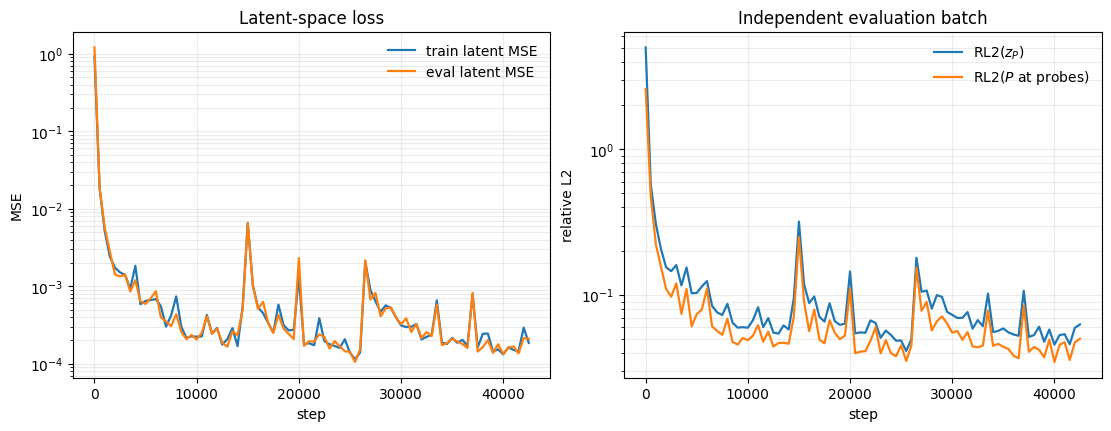

History CSV: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v2/operator_training_history.csv
History NPZ: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v2/operator_training_history.npz
Training curves: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v2/operator_training_curves.png
Final OL checkpoint: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v2/ol_params.msgpack
Latest OL checkpoint: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v2/ol_params_latest.msgpack


In [8]:
history_npz_path = ol_cfg.output_dir / "operator_training_history.npz"
history_csv_path = ol_cfg.output_dir / "operator_training_history.csv"

if not history_npz_path.exists():
    raise FileNotFoundError(f"找不到训练历史：{history_npz_path}")

with np.load(history_npz_path) as archive:
    history = {name: archive[name].copy() for name in archive.files}

steps = history["step"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].semilogy(
    steps,
    history["train_latent_mse"],
    label="train latent MSE",
    linewidth=1.6,
)
axes[0].semilogy(
    steps,
    history["eval_latent_mse"],
    label="eval latent MSE",
    linewidth=1.6,
)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[0].set_title("Latent-space loss")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].semilogy(
    steps,
    history["eval_latent_relative_l2"],
    label=r"RL2($z_P$)",
    linewidth=1.6,
)
axes[1].semilogy(
    steps,
    history["eval_physical_relative_l2"],
    label=r"RL2($P$ at probes)",
    linewidth=1.6,
)
axes[1].set_xlabel("step")
axes[1].set_ylabel("relative L2")
axes[1].set_title("Independent evaluation batch")
axes[1].grid(True, which="both", alpha=0.25)
axes[1].legend(frameon=False)

curve_path = ol_cfg.output_dir / "operator_training_curves.png"
fig.savefig(curve_path, dpi=200, bbox_inches="tight")
plt.show()

print("History CSV:", history_csv_path)
print("History NPZ:", history_npz_path)
print("Training curves:", curve_path)
print("Final OL checkpoint:", ol_cfg.output_dir / "ol_params.msgpack")
print("Latest OL checkpoint:", ol_cfg.output_dir / "ol_params_latest.msgpack")

## 9. 正式训练步骤

1. 保持 `OL_RUN_MODE = "smoke"`，完整运行 Notebook，确认 5 步训练和日志文件正常。
2. 将 `OL_RUN_MODE` 改为 `"full"`。
3. 重启内核并按顺序重新运行全部单元。
4. 长时间训练期间，可在另一个 Notebook 中反复读取 `operator_training_history.npz` 绘图；文件采用原子替换，不会读到半写入状态。

注意：当前实现不自动续训。再次运行训练单元会重新初始化 OL；已有 checkpoint 会被后续保存覆盖。

显存说明：评估默认使用独立小批量（每个尺度 16 个样本）和 256 个探针点，不会复制完整训练批次。如果服务器显存仍不足，可先把 `ol_eval_sample_size` 降到 4、把 `ol_eval_probe_points` 降到 64；这只影响监控指标的统计精度，不改变训练批量。